# Operation Cold Ledger  
## Visual Intelligence Briefing Notebook

### Commander's Intent
This notebook functions as the **visual analysis and briefing layer** of the Operation Cold Ledger environment.  
Its purpose is to transform transaction data into a format that supports:

- rapid situational understanding
- pattern recognition under uncertainty
- account-centric and network-aware review
- report-ready analytical language
- portfolio-grade presentation for GitHub and professional visibility

### Operational Role
This is **not** a generic exploratory notebook. It is designed as a **briefing product** that sits between raw analysis and final reporting.

It should help the analyst answer four questions quickly:

1. **Where is activity concentrated?**
2. **When does behavior deviate from baseline rhythm?**
3. **Which flows, partners, or periods deserve escalation?**
4. **What can be communicated clearly to a decision-maker?**

### Analytical Doctrine
All judgments in this notebook should remain:

- pattern-based
- evidence-led
- hypothesis-driven
- professionally constrained

The goal is not to force attribution.  
The goal is to **surface structure, concentration, timing irregularity, and behavioral signal**.

### Briefing Standard
Every chart in this notebook should support one or more of the following:

- executive readout
- analyst escalation
- technical reporting
- GitHub portfolio presentation

This notebook therefore serves as both an **analytical instrument** and a **presentation artifact**.

## Briefing Structure

This notebook is organized into the following operational sections:

1. Data Ingestion and Analytical Readiness  
2. Transaction Value Distribution  
3. Inflow vs Outflow by Period  
4. Net Flow Review  
5. Pending / Friction Activity  
6. Transaction Volume by Hour  
7. Country Exposure  
8. Counterparty Concentration  
9. Subject Account Focus  
10. Executive Visual Summary  
11. Portfolio and Dissemination Note

Use it like a briefing deck: review the chart, read the note, then decide what deserves escalation.

In [1]:
from pathlib import Path
import sys
import importlib
import matplotlib.pyplot as plt
import pandas as pd

CURRENT = Path.cwd().resolve()

if (CURRENT / "src").exists():
    ROOT = CURRENT
elif (CURRENT.parent / "src").exists():
    ROOT = CURRENT.parent
else:
    raise FileNotFoundError("Could not find project root containing 'src' folder.")

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

plt.rcParams["figure.figsize"] = (16, 7)
plt.rcParams["figure.dpi"] = 130

In [2]:
import src.load_data as load_data_module
import src.clean_data as clean_data_module
import src.visualization as visualization_module

importlib.reload(load_data_module)
importlib.reload(clean_data_module)
importlib.reload(visualization_module)

from src.load_data import load_transactions
from src.clean_data import clean_transaction_data
from src.visualization import (
    plot_transaction_distribution,
    plot_transactions_by_country,
    plot_counterparty_concentration,
    plot_account_activity,
    plot_inflow_outflow_by_period,
    plot_daily_net_flow,
    plot_pending_activity_by_period,
    plot_transaction_volume_by_hour,
    plot_account_status_changes,
    plot_account_inflow_outflow,
)

## Data Ingestion and Analytical Readiness

This stage confirms that the visual layer is operating on the **cleaned analytical dataset**, not on the raw observational layer.

### Why this matters
Visual outputs are only useful if the underlying data has already passed through normalization and integrity checks.  
In this workflow, the visual layer depends on:

- timestamp normalization
- amount coercion
- categorical cleanup
- derived analytical features
- duplicate control
- validation flags

### Expected Outcome
By the end of this section, the analyst should be confident that the charts generated below reflect the cleaned case environment and can be used for structured interpretation.

In [3]:
data_path = ROOT / "data" / "raw" / "synthetic_transactions.csv"

df = load_transactions(str(data_path))
df_clean = clean_transaction_data(df)

print("Raw shape:", df.shape)
print("Clean shape:", df_clean.shape)
df_clean.head()

[CLEANING] Removed 0 duplicate rows
Raw shape: (12104, 18)
Clean shape: (12104, 25)


,transaction_id,account_id,timestamp,amount,currency,transaction_type,counterparty,country,channel,device_id,...,risk_score,is_flagged,notes,hour,is_night,amount_abs,is_outlier,missing_timestamp,missing_amount,invalid_amount
0,TXN-000003,ACC-1001,2024-01-01 00:00:00,7711,usd,outbound,CTR-137,fr,mobile,DEV-2519,...,95,True,anomalous burst,0,1,7711,False,False,False,False
1,TXN-000004,ACC-1001,2024-01-01 00:03:00,11803,usd,outbound,CTR-206,fr,mobile,DEV-2519,...,90,True,anomalous burst,0,1,11803,False,False,False,False
2,TXN-000005,ACC-1001,2024-01-01 00:06:00,10733,usd,outbound,CTR-885,fr,mobile,DEV-2519,...,90,True,anomalous burst,0,1,10733,False,False,False,False
3,TXN-000006,ACC-1001,2024-01-01 00:06:00,11554,usd,outbound,CTR-864,fr,mobile,DEV-2519,...,90,True,anomalous burst,0,1,11554,False,False,False,False
4,TXN-000007,ACC-1001,2024-01-01 00:08:00,12820,usd,outbound,CTR-283,fr,web,DEV-2519,...,90,True,anomalous burst,0,1,12820,False,False,False,False


## Visual Briefing 1 — Transaction Value Distribution

### Analytical Question
Is the case environment dominated by routine-value activity, or is a smaller subset of higher-value transactions carrying disproportionate significance?

### Why this matters
Value distribution is one of the fastest ways to identify whether:
- financial behavior is broadly stable
- a small number of movements dominate the case
- high-value activity may deserve prioritization

### What to look for
- right-skewed distributions
- thin but significant high-value tails
- visible clustering away from median behavior
- evidence that outlier-sensitive review is justified

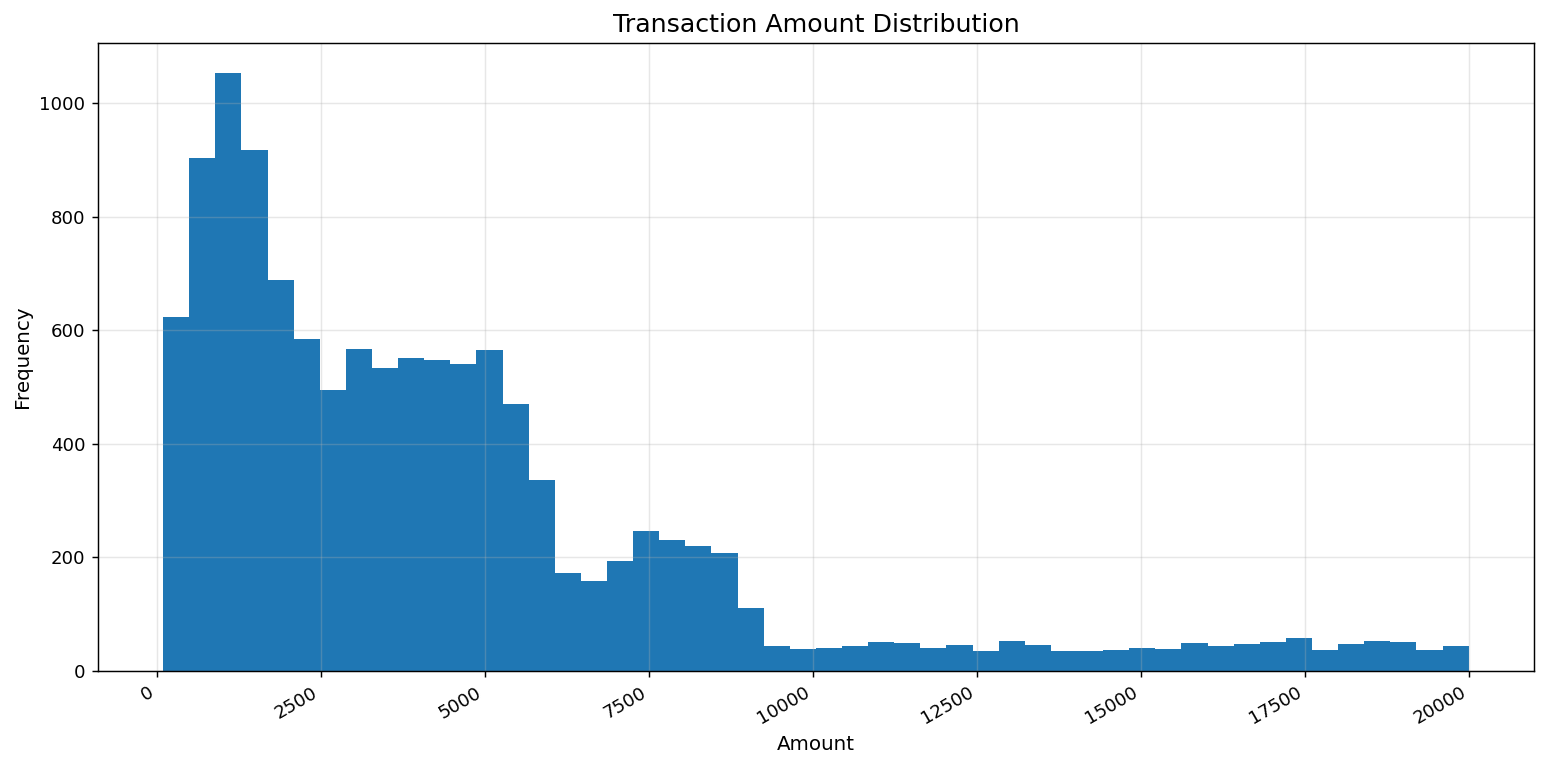

In [4]:
plot_transaction_distribution(
    df_clean,
    save_path=str(ROOT / "assets" / "diagrams" / "transaction_distribution.png")
)

### Reporting Note

**Assessment language candidate:**

The value distribution appears uneven, with a smaller subset of transactions contributing disproportionate financial weight. This pattern supports the analytical relevance of high-value review and strengthens the case for outlier-aware anomaly assessment.

## Visual Briefing 2 — Inflow vs Outflow by Period

### Analytical Question
During which periods does movement become directionally imbalanced, and does the flow rhythm suggest ordinary activity or structured sequencing?

### Why this matters
A simple inbound/outbound comparison can expose:
- outbound-heavy movement windows
- balancing inflows after concentrated outflows
- timing asymmetry that would be easy to miss in tabular review

### What to look for
- compressed outflow spikes
- uneven inbound support
- repeated directional imbalance
- periods that appear staged rather than organic

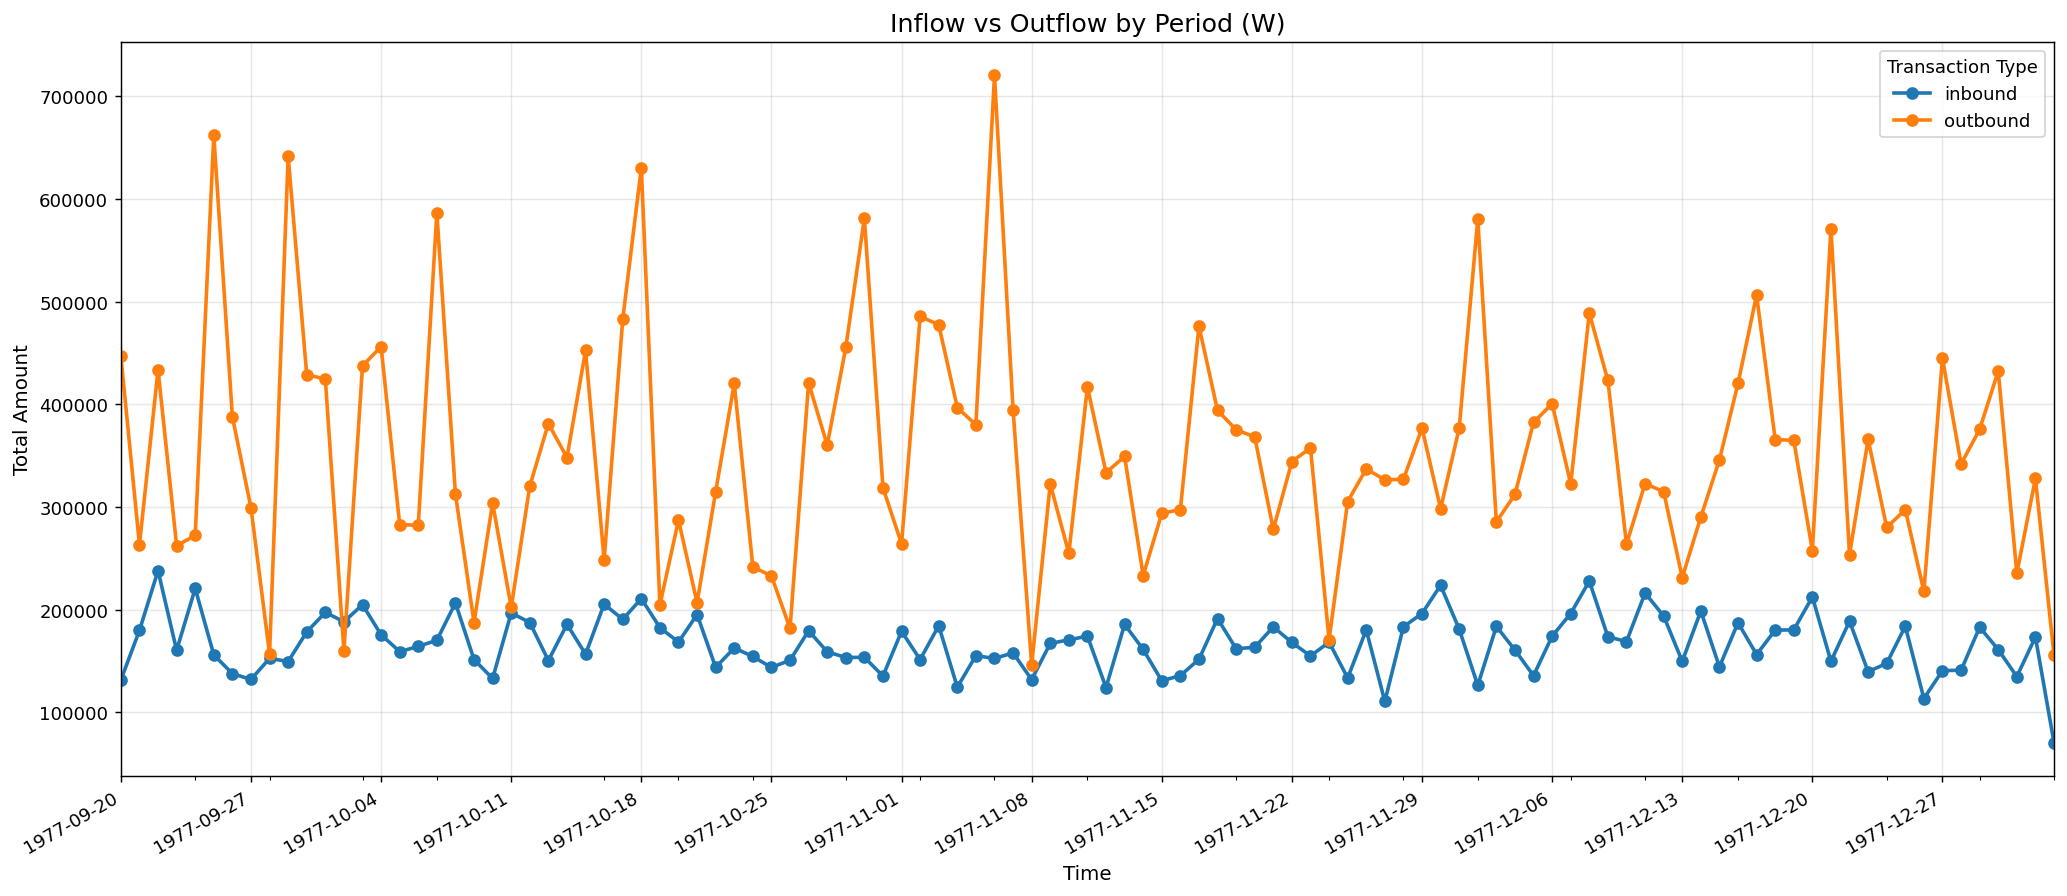

In [5]:
plot_inflow_outflow_by_period(
    df_clean,
    period="W",
    save_path=str(ROOT / "assets" / "diagrams" / "weekly_inflow_outflow.png")
)

### Reporting Note

**Assessment language candidate:**

Period-based flow review indicates that movement is not evenly distributed across the observed timeline. Several windows show visible asymmetry between inbound and outbound activity, which is more consistent with concentrated movement behavior than with stable transactional rhythm.

## Visual Briefing 3 — Net Flow

### Analytical Question
When transaction noise is reduced to net balance, do we observe smooth continuity or abrupt directional swings?

### Why this matters
Net flow compresses complexity and is useful for identifying:
- extractive periods
- accumulation periods
- abrupt reversals
- imbalance severity over time

### What to look for
- strong negative intervals
- sudden reversals
- clustered directional behavior
- flow instability across successive periods

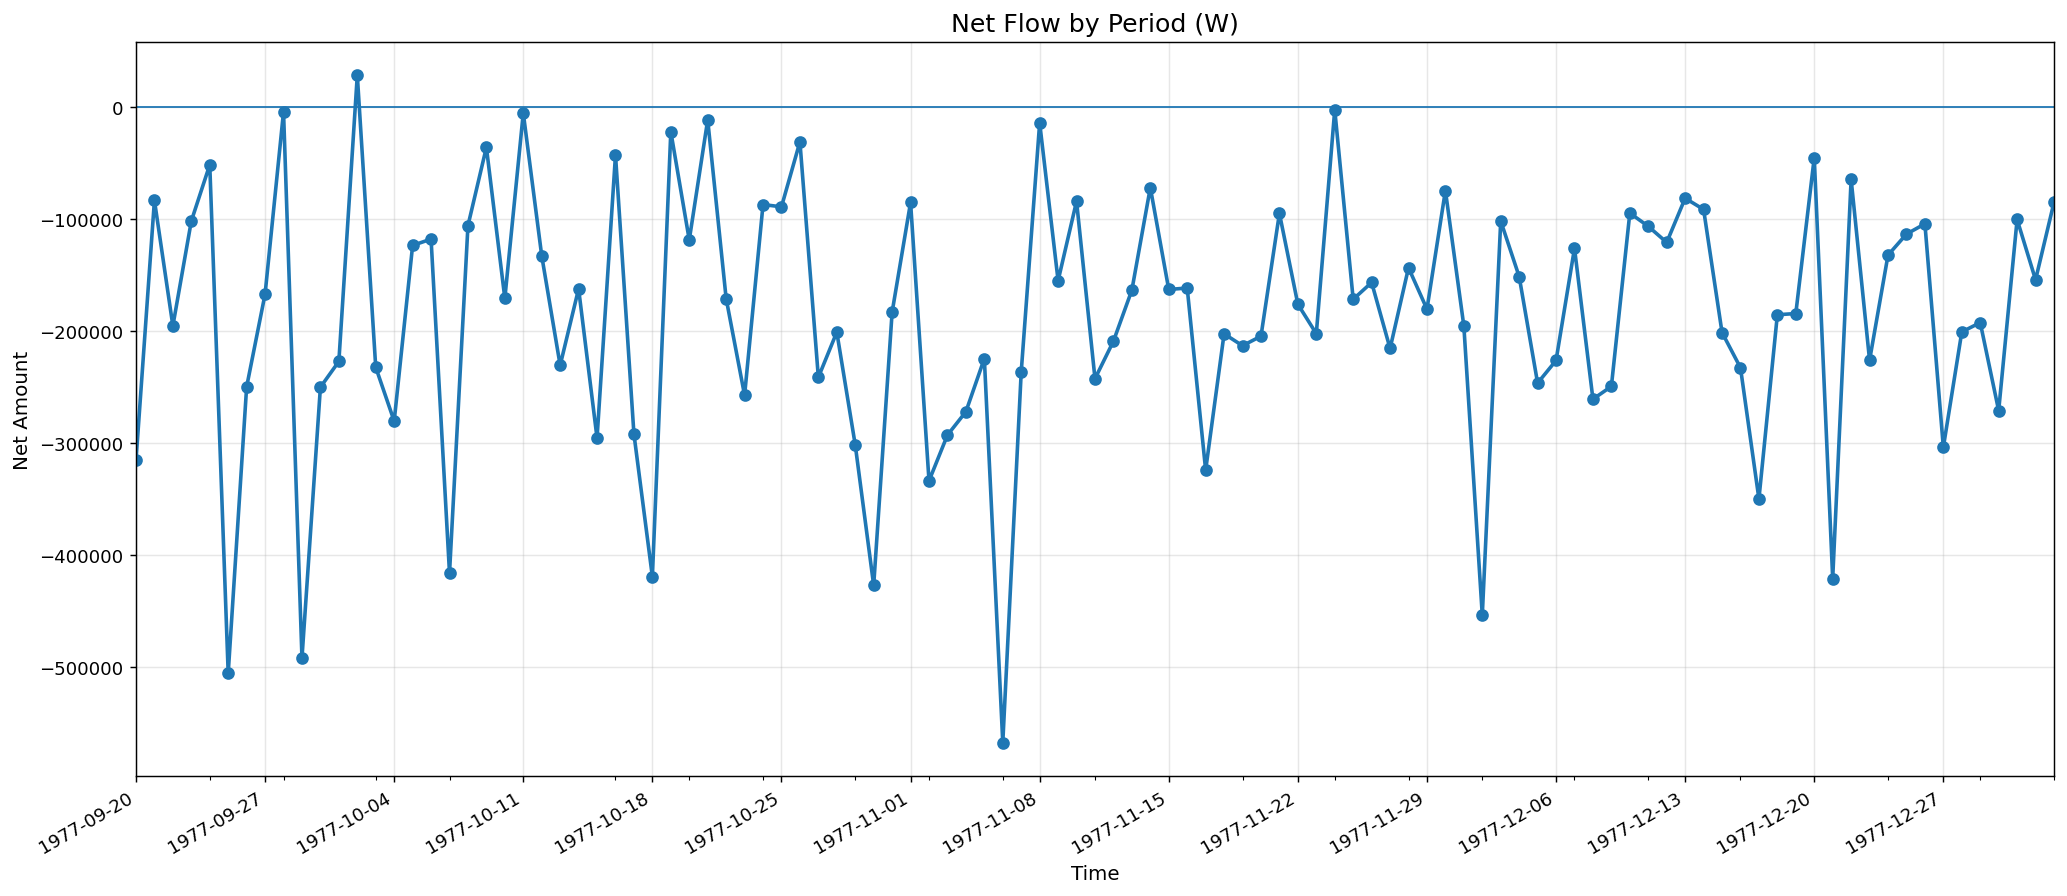

In [6]:
plot_daily_net_flow(
    df_clean,
    period="W",
    save_path=str(ROOT / "assets" / "diagrams" / "weekly_net_flow.png")
)

### Reporting Note

**Assessment language candidate:**

Net flow varies unevenly across the review period, with selected windows showing pronounced directional imbalance. These fluctuations suggest episodic movement intensity rather than continuous financial behavior and reinforce the value of burst-aware timeline review.

## Visual Briefing 4 — Pending / Friction Activity

### Analytical Question
Are execution frictions distributed normally, or do they cluster around analytically important periods?

### Why this matters
In the current synthetic environment, pending states can function as signals of:
- transactional friction
- review-sensitive execution windows
- hold-like interruptions
- non-routine processing conditions

### What to look for
- concentrated pending windows
- friction around active movement periods
- visible timing overlap with irregular account behavior

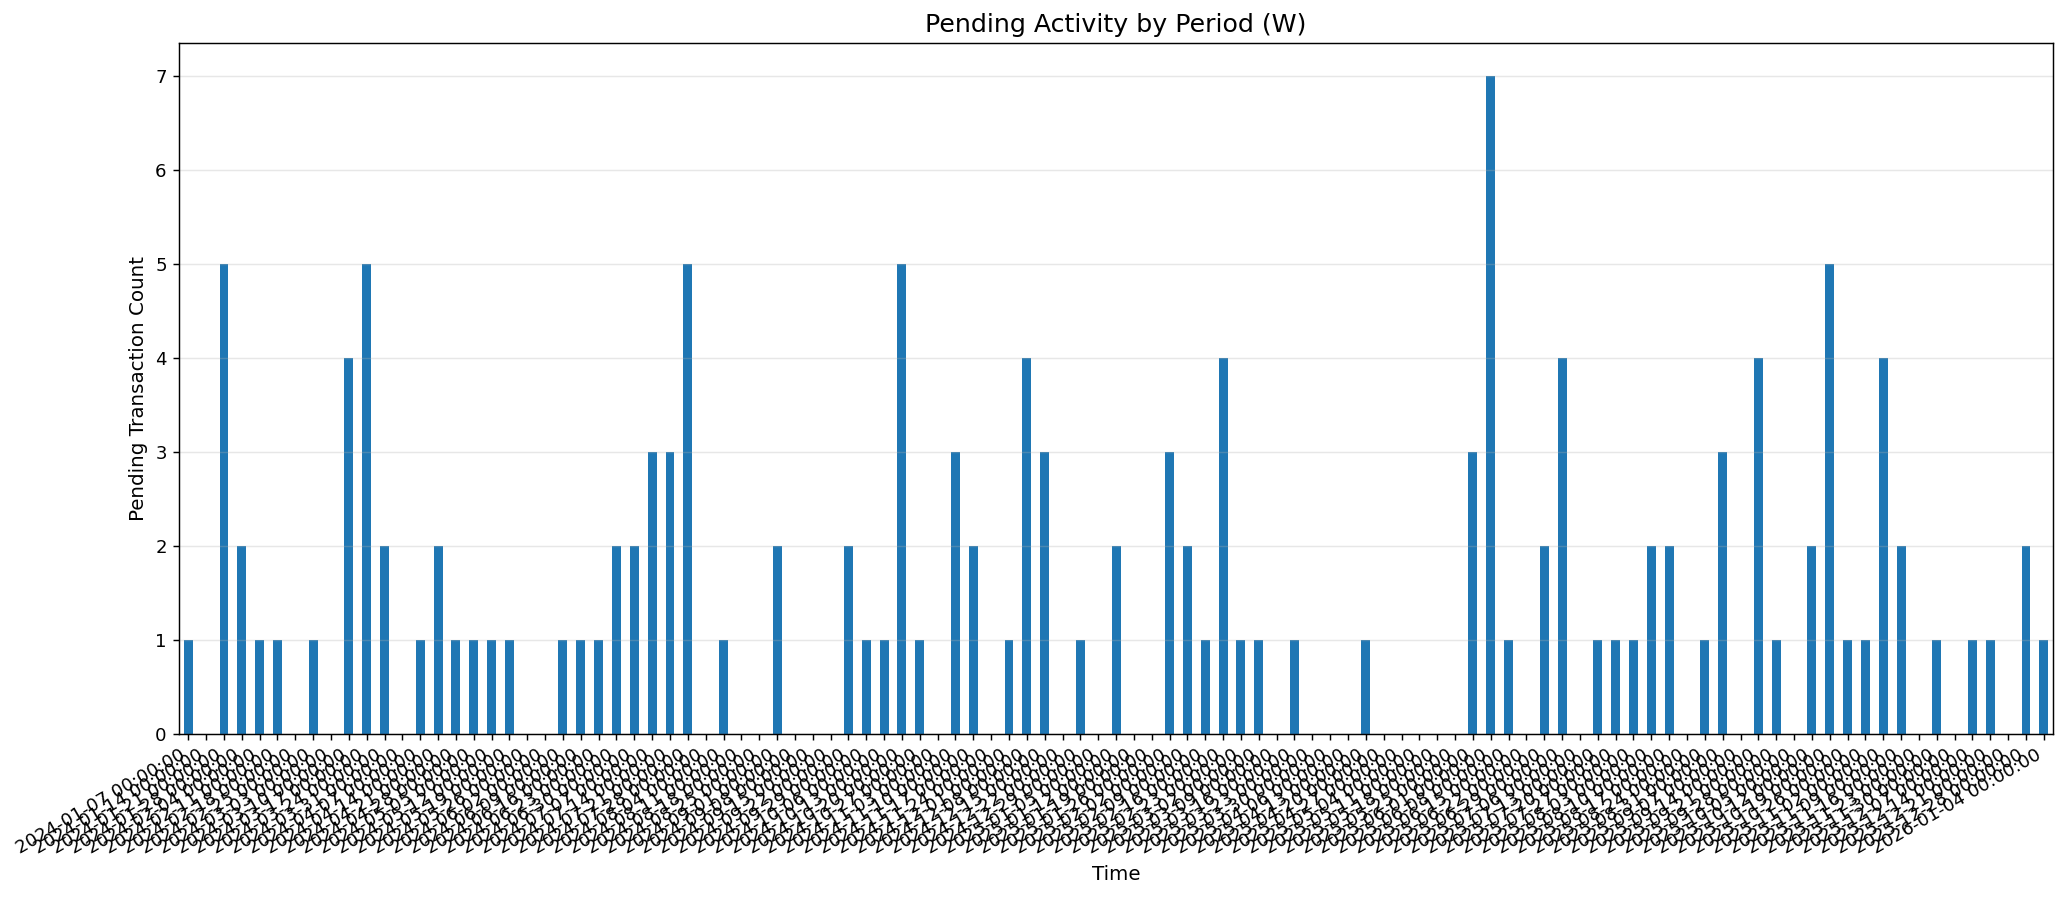

In [7]:
plot_pending_activity_by_period(
    df_clean,
    period="W",
    save_path=str(ROOT / "assets" / "diagrams" / "weekly_pending_activity.png")
)

### Reporting Note

**Assessment language candidate:**

Pending-state activity is not uniformly distributed across the timeline. Concentrated friction windows may indicate review-sensitive periods or transactional conditions that differ from steady-state execution.

## Visual Briefing 5 — Transaction Volume by Hour

### Analytical Question
Does activity align with ordinary operating rhythm, or is meaningful volume appearing in low-expectation hours?

### Why this matters
Time-of-day concentration is a high-value analytical lens because it can reveal:
- low-hour execution
- non-routine timing
- overlap with anomaly flags already identified elsewhere in the pipeline

### What to look for
- night-hour presence
- uneven hourly peaks
- bursts outside expected windows
- timing patterns that support escalation

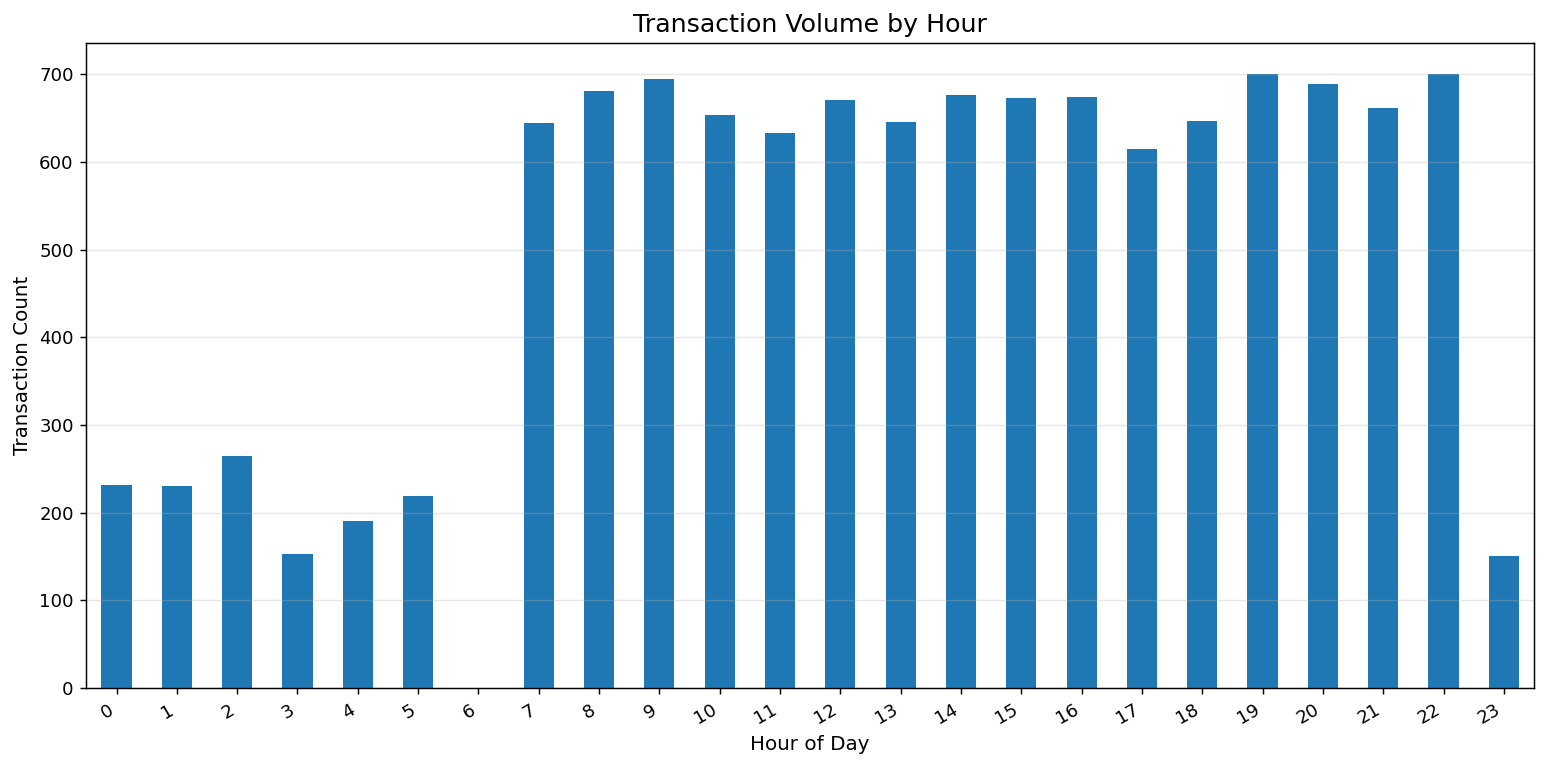

In [8]:
plot_transaction_volume_by_hour(
    df_clean,
    save_path=str(ROOT / "assets" / "diagrams" / "hourly_transaction_volume.png")
)

### Reporting Note

**Assessment language candidate:**

Hourly transaction activity is not confined to conventional operating windows. The presence of low-hour execution supports earlier anomaly findings and strengthens the analytical case for timeline-linked behavioral review.

## Visual Briefing 6 — Country Exposure

### Analytical Question
Is activity geographically concentrated, or does the case environment show broader exposure diversity?

### Why this matters
Country-level review helps distinguish:
- stable geographic concentration
- widened operational footprint
- cross-border variation requiring additional interpretation

### What to look for
- dominant locations
- exposure imbalance
- meaningful geographic spread
- support for cross-border irregularity review

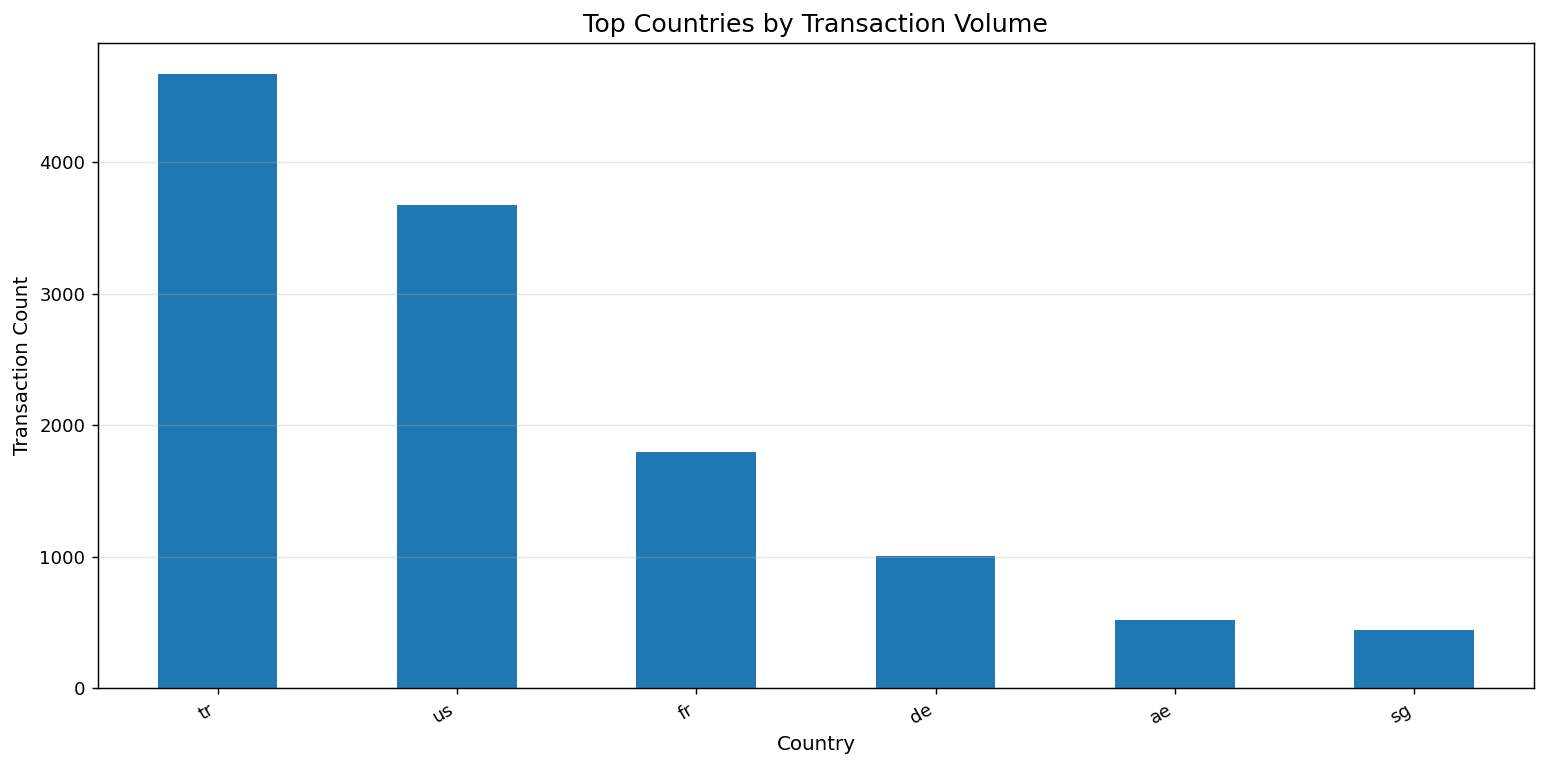

In [9]:
plot_transactions_by_country(
    df_clean,
    save_path=str(ROOT / "assets" / "diagrams" / "country_transaction_volume.png")
)

### Reporting Note

**Assessment language candidate:**

Country-level exposure appears uneven, with a limited subset of locations carrying the majority of visible activity. This supports continued review of concentration patterns and cross-border behavioral variation within the synthetic case environment.

## Visual Briefing 7 — Counterparty Concentration

### Analytical Question
Is account behavior distributed across many partners, or concentrated around a narrower set of recurring entities?

### Why this matters
Counterparty concentration can support:
- relationship-aware review
- repeated-route detection
- identification of structurally important entities
- escalation toward linkage analysis

### What to look for
- repeated counterparties
- apparent hubs
- strong concentration patterns
- evidence of narrow routing behavior

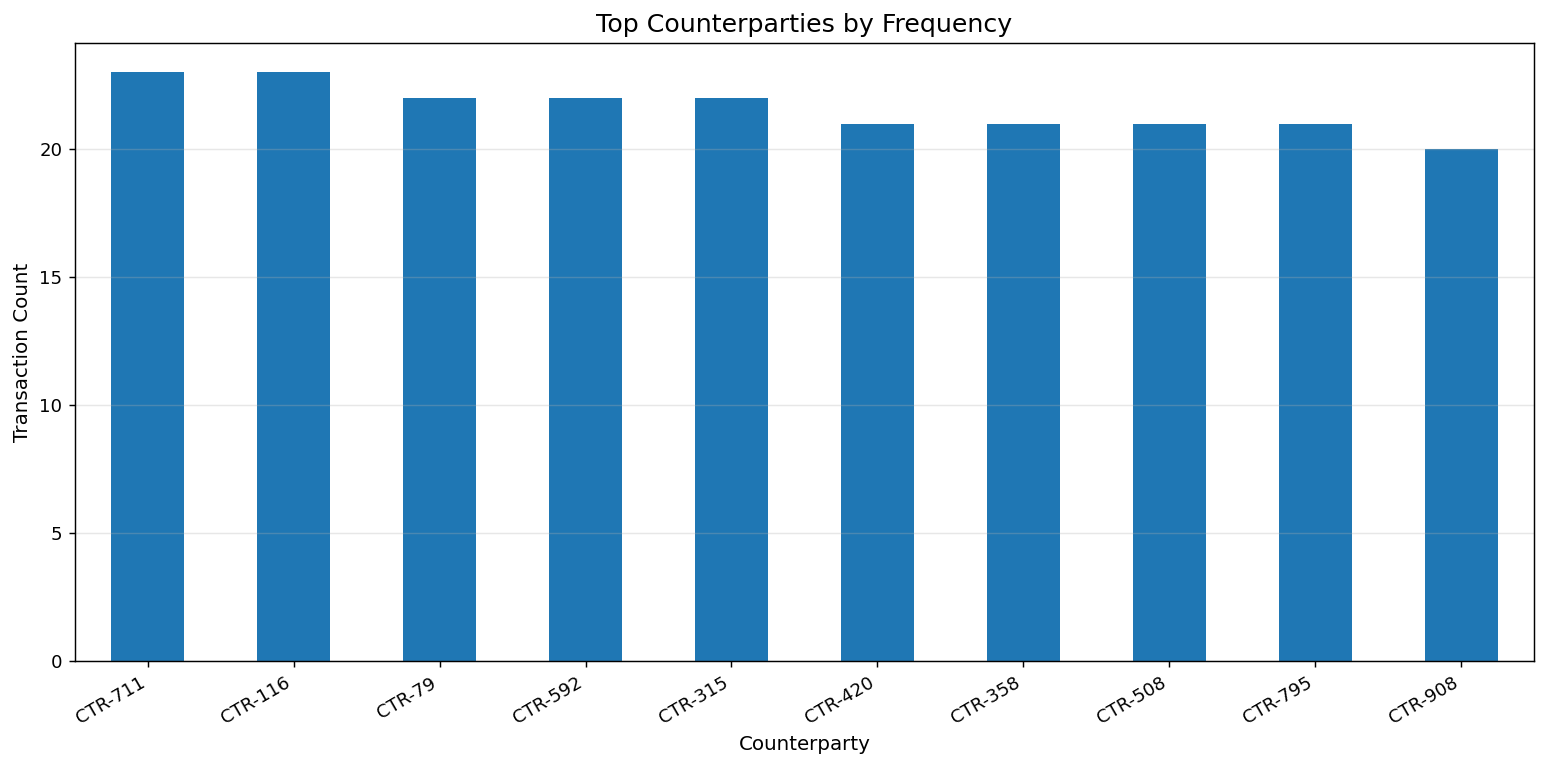

In [10]:
plot_counterparty_concentration(
    df_clean,
    save_path=str(ROOT / "assets" / "diagrams" / "counterparty_concentration.png")
)

### Reporting Note

**Assessment language candidate:**

Counterparty frequency is unevenly distributed, with a small subset of entities recurring across the case environment. This concentration pattern supports relationship-aware review and may indicate structurally important counterparties within the observed transaction system.

## Visual Briefing 8 — Subject Account Focus

### Analytical Question
When the case is reduced to the priority account, does the behavior appear stable, cyclical, or burst-driven?

### Why this matters
An account-centric view helps compress the broader case into an interpretable behavioral picture. It is also one of the strongest products for:

- analyst review
- executive briefings
- GitHub presentation
- scenario storytelling

### What to look for
- abrupt value spikes
- burst activity rather than steady flow
- account-change clustering
- signs of event-sensitive movement

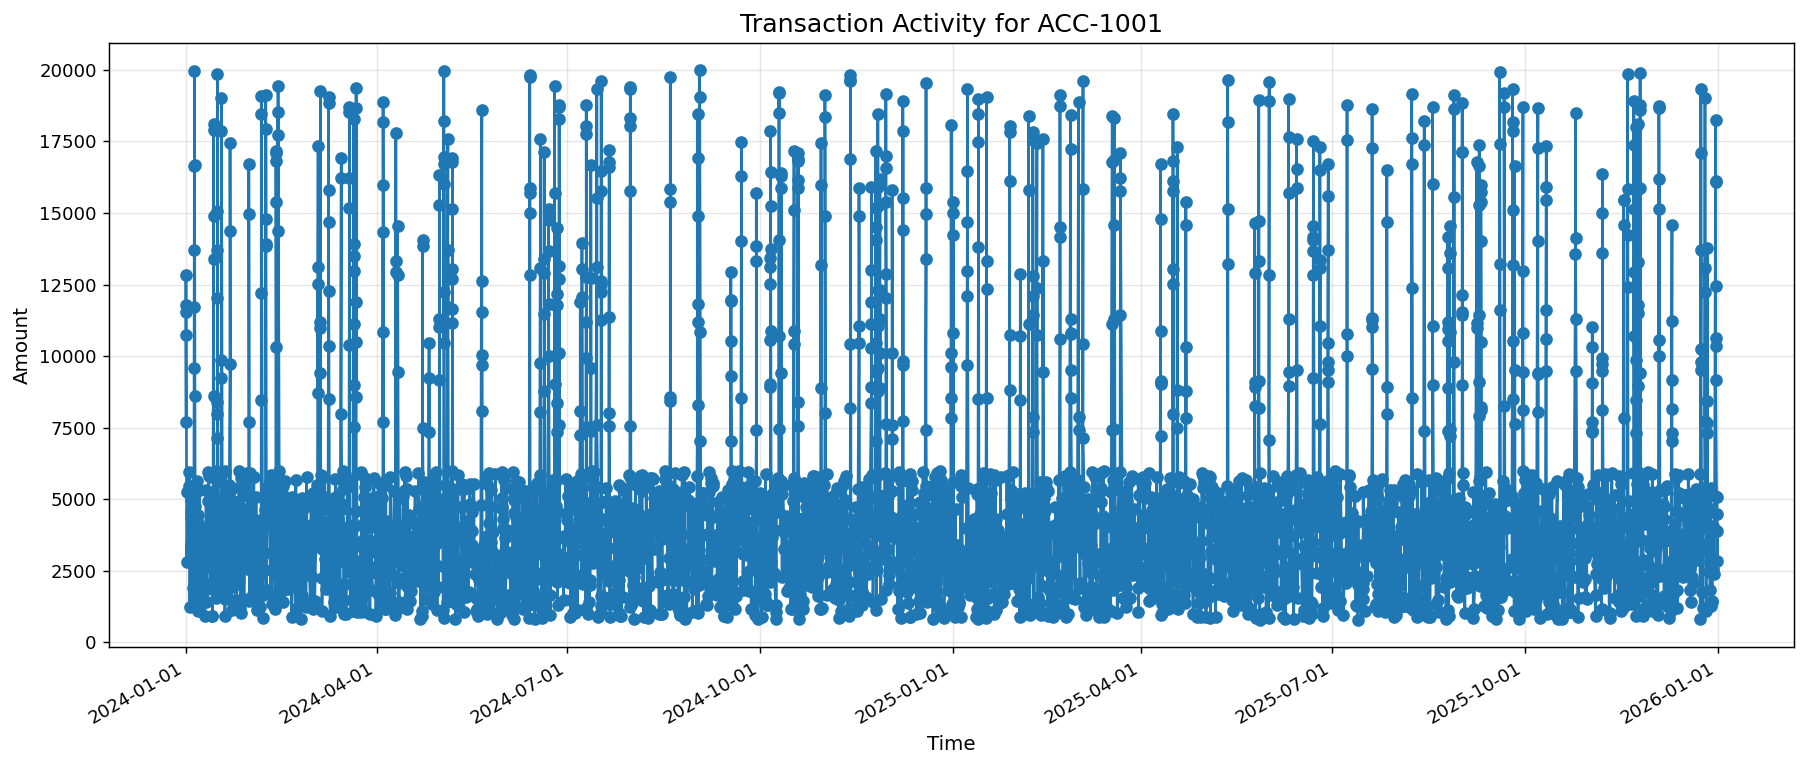

In [11]:
plot_account_activity(
    df_clean,
    "ACC-1001",
    save_path=str(ROOT / "assets" / "diagrams" / "acc1001_activity.png")
)

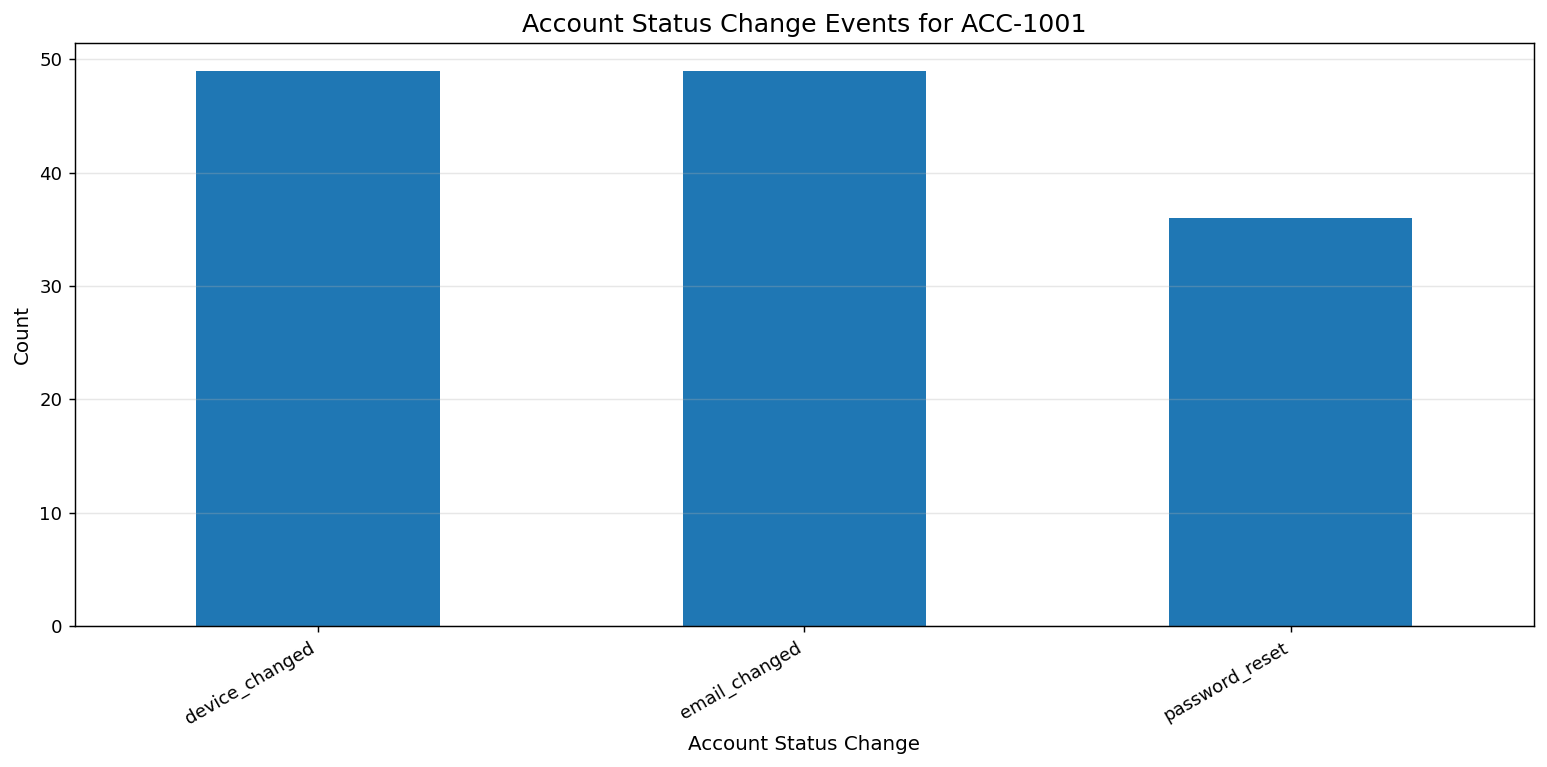

In [12]:
plot_account_status_changes(
    df_clean,
    "ACC-1001",
    save_path=str(ROOT / "assets" / "diagrams" / "acc1001_status_changes.png")
)

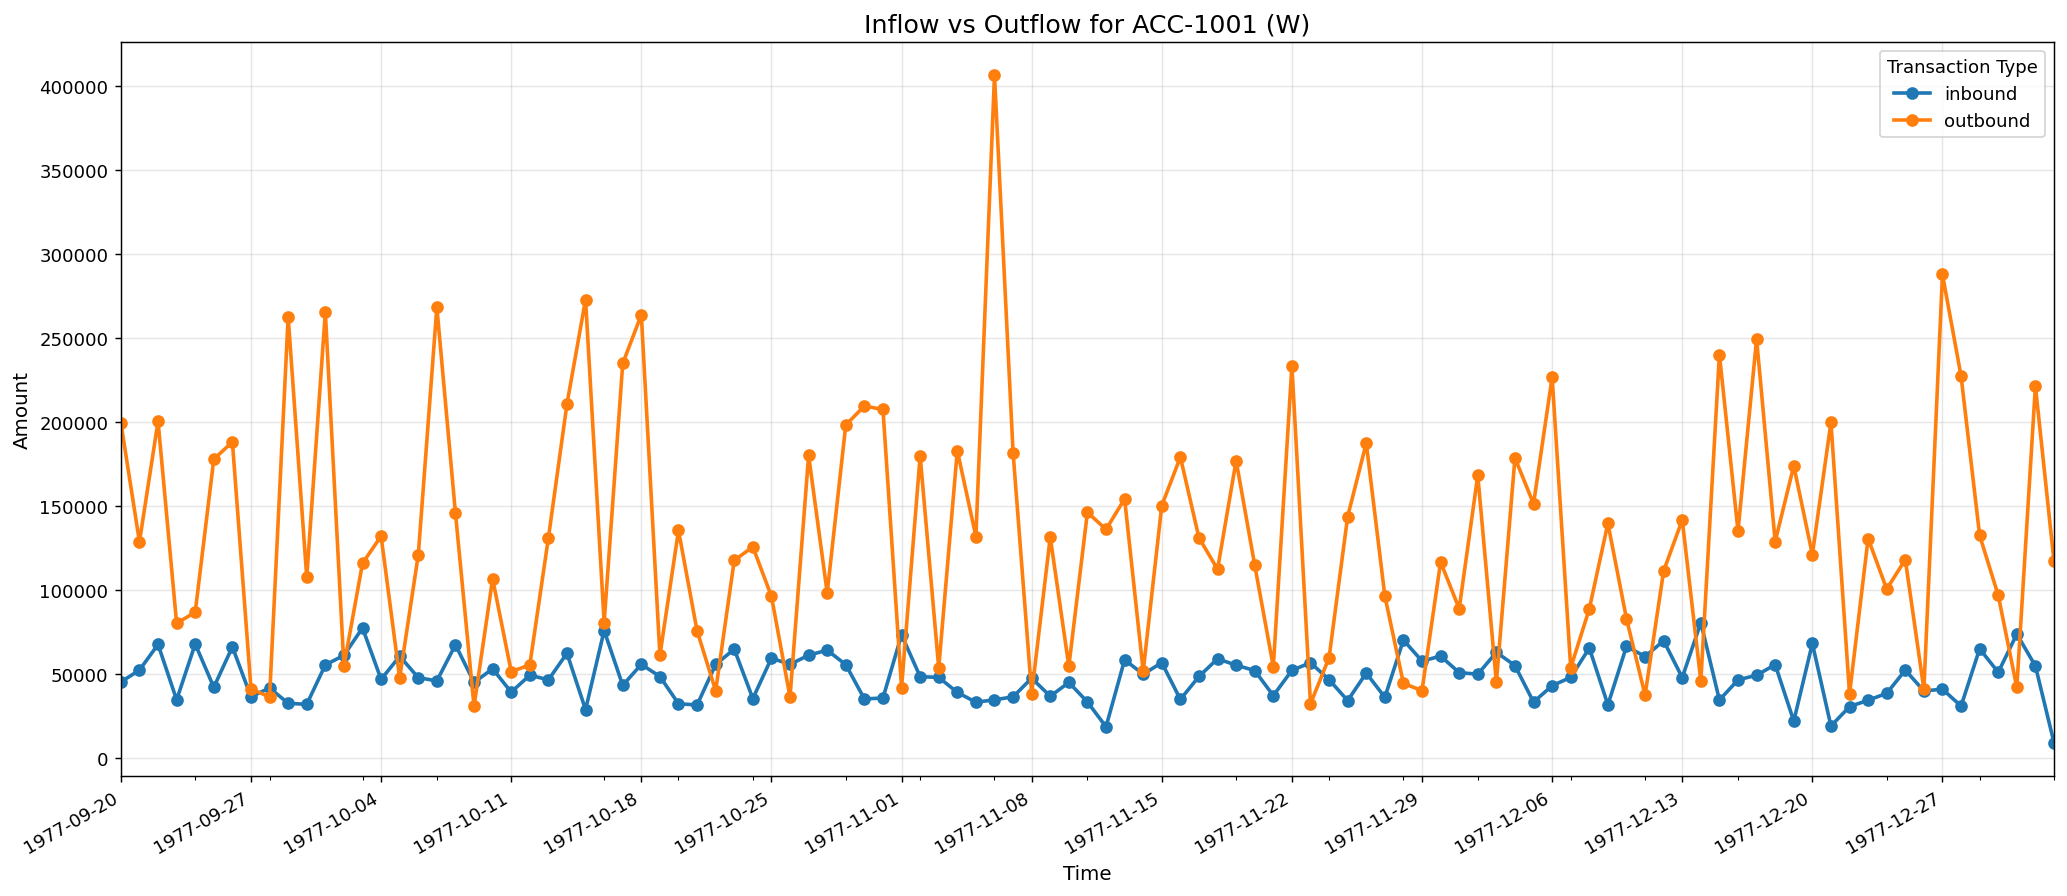

In [13]:
plot_account_inflow_outflow(
    df_clean,
    "ACC-1001",
    period="W",
    save_path=str(ROOT / "assets" / "diagrams" / "acc1001_weekly_inflow_outflow.png")
)

### Reporting Note

**Assessment language candidate:**

The subject-linked account does not present as a stable-flow environment. Visual review suggests concentrated movement periods, event-sensitive behavior, and irregular directional balance, collectively supporting elevated behavioral irregularity assessment.

## Executive Visual Summary

### High-Level Readout
The visual intelligence layer supports several recurring analytical themes:

- transaction behavior is uneven rather than stable
- higher-value movement carries disproportionate significance
- selected periods show visible outbound concentration
- pending-state friction appears clustered rather than uniform
- subject-linked activity is burst-oriented rather than continuous
- counterparty and geography patterns support relationship-aware review

### Operational Interpretation
Taken together, these visuals do not provide definitive attribution.  
They do, however, strengthen the case for treating the environment as one characterized by:

- timing irregularity
- directional imbalance
- concentrated movement
- structurally relevant counterparties
- non-uniform behavioral rhythm

### Executive Framing
This notebook should be used as a **briefing layer**, not as a standalone adjudication system.

Its principal value lies in:

- compressing complexity
- surfacing concentration
- accelerating analyst judgment
- improving readability for non-technical audiences
- strengthening presentation quality for public-facing portfolio use

## Portfolio and Dissemination Note

To maximize GitHub and professional presentation value, this notebook should be integrated as the project's dedicated **Visual Intelligence Layer**.

### Recommended deployment
1. Save 4–6 strong charts into `assets/diagrams/`
2. Embed 2–3 of the best visuals into `README.md`
3. Keep this notebook as the main visual briefing artifact
4. Reference it directly from the README and reporting documents
5. Use the chart language here as the basis for executive and analyst summaries

### Positioning advantage
This structure makes the repository read less like a notebook collection and more like a layered analytical platform:

- data generation
- cleaning and integrity
- anomaly detection
- timeline reconstruction
- relationship mapping
- visualization and briefing
- intelligence-style reporting

That architecture is what gives the project professional weight.

## Analyst Writing Discipline

When converting visuals into report language, keep the following rules in force:

- separate **observation** from **assessment**
- avoid definitive attribution unless the evidence supports it
- prefer phrases such as *consistent with*, *suggests*, *supports further review*, and *warrants escalation*
- treat concentration, timing irregularity, and asymmetry as indicators, not verdicts
- write for both analysts and decision-makers

A strong visual notebook does not just show charts.  
It teaches the reader **how to think about the chart**.